In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [2]:
data=pd.read_csv(r'D:\Documents\PICT SEM 8\LP-5\DL\Assign4\goog.csv')
data.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [3]:
data.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [4]:
data.shape

(61, 6)

In [5]:
scaler=MinMaxScaler(feature_range=(0,1))

In [6]:
data = data["Open"]
data = data.values.reshape(-1, 1)

In [7]:
data_scaled=scaler.fit_transform(data)

In [8]:
data_length=len(data_scaled)
train_data_len=int(data_length*0.8)



In [9]:
train_data=data_scaled[:train_data_len]
test_data=data_scaled[train_data_len:]

In [10]:
def create_dataset(data_scaled):
    x=[]
    y=[]
    for i in range(5,len(data_scaled)):
        x.append(data_scaled[i-5:i])
        y.append(data_scaled[i])
    return np.array(x),np.array(y)

x_train,y_train=create_dataset(train_data)
x_test,y_test=create_dataset(test_data)
        

In [ ]:
model=Sequential()
model.add(SimpleRNN(50,return_sequences=True,input_shape=(5,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))
model.compile(optimizer="adam",loss="mean_squared_error")
model.summary()

C:\Users\tanay\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 5, 50)               │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.fit(x_train,y_train,epochs=10,validation_split=0.05)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 0.3091 - val_loss: 0.0237
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - loss: 0.0479 - val_loss: 0.2061
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.1160 - val_loss: 0.0518
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - loss: 0.0349 - val_loss: 0.0120
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.0224 - val_loss: 0.0943
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - loss: 0.0525 - val_loss: 0.0903
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.0455 - val_loss: 0.0273
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - loss: 0.0188 - val_loss: 4.3747e-04
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - loss: 0.0125 - val_loss: 0.0167
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - loss: 0.0246 - val_loss: 0.0225


In [13]:
predict=model.predict(x_test)
predict=scaler.inverse_transform(predict)
real=scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step


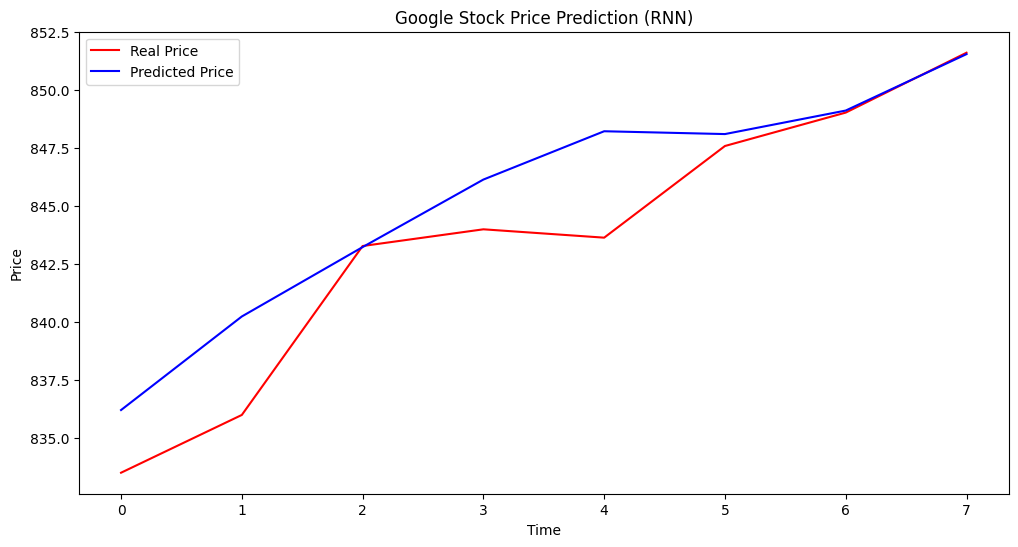

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(real, color='red', label='Real Price')
plt.plot(predict, color='blue', label='Predicted Price')
# Increase Y-axis scale
plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()